# <span style="color:blue;">OpenPTV-Python-GPU Feature Tutorial</span>

Please use the following link to run this notebook from Google Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ali-sh-96/openptv-python-gpu/blob/main/openptv_gpu/tutorials/openptv_python_gpu_feature_tutorial.ipynb)

## <span style="color:blue;">Introduction</span>

This tutorial demonstrates the use of two feature extraction methods, adaptive Gaussian thresholding (AGT) and the Laplacian of Gaussian (LoG), in OpenPTV-Python-GPU for particle identification. The dataset consists of both synthetic and experimental image pairs. The synthetic images are vortex fields obtained from the PIV Challenge database (http://www.pivchallenge.org/pub/#b
), while the experimental images correspond to low-Reynolds-number separated flow over an airfoil, acquired in the Turbulence Research Lab at the University of Toronto. The synthetic images have a resolution of 512 by 512 pixels squared, whereas the experimental images are significantly larger, at 2052 by 4606 pixels square, approximately 13.9 MB each. Particle detection results are presented for both AGT and LoG methods on the synthetic dataset, while only the LoG method is applied to the experimental images.


In `openptv-python-gpu`, the feature extraction method is selected by setting `particle_method=`_`"agt"`_ or _`"log"`_. The adaptive Gaussian thresholding (AGT) used here is the same implementation as in OpenCV (https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html), and is not GPU-native. Simply put, AGT is a dynamic thresholding method that allows a local threshold to be used for image binarization, where the threshold value is a Gaussian-weighted sum of the neighbourhood values minus a constant C, determined by the parameter `threshold` in `openptv-python-gpu`. The value of `threshold` can be a real number or a tuple of two real values to specify the C constant for each image in the pair individually.

The Laplacian of Gaussian (LoG), on the other hand, is essentially a two-step spatial filter used for blob detection, combining Gaussian smoothing to reduce noise with the Laplacian operator to detect intensity changes. In `openptv-python-gpu`, setting `threshold` specifies the threshold level used to binarize the normalized intensity.

The parameter `particle_method=`_`"gaussian"`_, _`"parabolic"`_, or _`"centroid"`_ specifies the method used to approximate the subpixel peak location. The parameter `particle_size` is either an integer or a tuple of two integers, controlling the size of the neighbourhood area in AGT or the value of sigma in LoG. A mask may be defined using the input `mask` to set the image intensity at specific indices to zero and exclude them from feature extraction. Otherwise, `mask` is set to `None` by default.

## <span style="color:blue;">Dependencies</span>

The `openptv-python-gpu` package primarily depends on `cupy` and `numpy`, although `cv2` is also required to use AGT particle detection. The choice of other libraries, such as those needed to load or save images, is left to the user. In this tutorial, opencv-python is used to load images, as it is also required by the package itself.

In [1]:
#@title Import the needed libraries
#@markdown Run this block to import the dependencies.
import sys
import os
from glob import glob
import cv2

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [2]:
#@title Install `openptv-python-gpu`
#@markdown Run this block to install `openptv-python-gpu`.
!git clone https://github.com/ali-sh-96/openptv-python-gpu
openptv_path = "/content/openptv-python-gpu/"
sys.path.append(openptv_path)
from openptv_gpu.gpu_process import ptv_gpu

# Get the path to the tutorials folder.
tutorial_path = os.path.join(openptv_path, 'openptv_gpu/tutorials/')

Cloning into 'openptv-python-gpu'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 119 (delta 15), reused 27 (delta 11), pack-reused 84 (from 1)
Receiving objects: 100% (119/119), 57.82 MiB | 26.35 MiB/s, done.
Resolving deltas: 100% (46/46), done.


## <span style="color:blue;">Vortex Test Case</span>

This section demonstrates the use of the package on a pair of synthetic images representing a strong vortex, with variations in seeding concentration and particle image size. In this case, AGT is used to extract particle centroids. Compared to LoG, AGT generally detects a larger number of features, as it can effectively separate overlapping particles when the threshold and particle size are chosen appropriately. However, a key limitation of AGT is its sensitivity to noise, which can lead to false detections in experimental data. This issue is particularly pronounced in wind tunnel measurements, where small smoke particles and background noise are common. For the synthetic images used here, these effects are absent, which may give the impression that LoG is inferior. The next section, using real wind tunnel images, highlights the advantages of the LoG method.

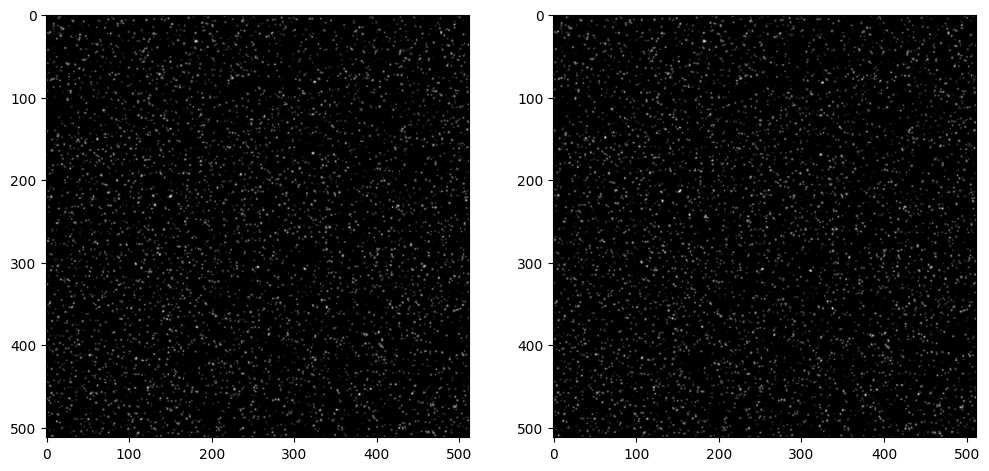

In [3]:
#@title Load the images
# Load the images.
test_dir = tutorial_path + "test1/"

# Show the images.
frame_a = cv2.imread(test_dir + "B005_1" + ".tif", cv2.IMREAD_ANYDEPTH)
frame_b = cv2.imread(test_dir + "B005_2" + ".tif", cv2.IMREAD_ANYDEPTH)

fig, axs = plt.subplots(1, 2, figsize=(12,10))
axs[0].imshow(frame_a, cmap=plt.cm.gray)
axs[1].imshow(frame_b, cmap=plt.cm.gray)

# Modify tick labels and ticks.
ticks_step = 100
wd, ht = frame_a.shape
for ax in axs:
    ax.set_xticks(range(0, wd, ticks_step))
    ax.set_yticks(range(0, ht, ticks_step))

plt.show()

In [4]:
#@title Feature extraction settings
#@markdown The shape of the images is `(512, 512)`.
frame_shape = (512, 512) #@param {type:"raw"}
particle_method = "agt" #@param ["agt", "log"] {type:"string"}
subpixel_method = "gaussian" #@param ["gaussian", "centroid", "parabolic"] {type:"string"}
threshold = -3 #@param {type:"raw"}
particle_size = 1 #@param {type:"raw"}
mask = None #@param {type:"raw"}

In [5]:
#@title Perform feature extraction
#@markdown Run this block to identify the particles.
# Initialize the process.
process = ptv_gpu(frame_shape,
                  particle_method=particle_method,
                  subpixel_method=subpixel_method,
                  threshold=threshold,
                  particle_size=particle_size,
                  mask=mask)

coords_a, coords_b = process.get_coords(frame_a, frame_b)
print('A total of {} particles were detected in frame_a and {} in frame_b.'.format(len(coords_a), len(coords_b)))

A total of 4960 particles were detected in frame_a and 4958 in frame_b.


In [6]:
#@title Visualize the detected particles
#@markdown Specify the marker size and color.
marker_size = 20 #@param {type:"slider", min:1, max:100, step:1}
marker_color = "blue" #@param ["blue", "red", "yellow"] {type:"string"}

def animate_centroids(frame1, coords1, frame2, coords2, interval=800):
    # Invert y before plotting the coordinates.
    y1, x1 = coords1[:, 0], coords1[:, 1]
    y2, x2 = coords2[:, 0], coords2[:, 1]

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    def draw_frame(frame, x, y, title):
        ax.clear()
        ax.imshow(frame, cmap='gray', origin='upper')
        ax.scatter(x, y, facecolors='none', edgecolors='blue', s=marker_size)
        ax.set_title(title)
        ax.axis('off')

    def update(i):
        if i % 2 == 0:
            draw_frame(frame1, x1, y1, "frame_a")
        else:
            draw_frame(frame2, x2, y2, "frame_b")

    ani = FuncAnimation(fig, update, frames=2, interval=interval)
    plt.close(fig)
    return HTML(ani.to_jshtml())

animate_centroids(frame_a, coords_a, frame_b, coords_b)

## <span style="color:blue;">Separated Flow Test Case</span>

This section demonstrates the use of the module on a pair of experimental PIV images acquired in a study of low-Reynolds-number separated flow over an airfoil. The airfoil partially occludes the images, and a mask could be applied to exclude this region from the analysis. The LoG method is an edge detector and may not reliably capture overlapping particles. However, it is inherently robust and produces relatively few false detections under complex experimental conditions. In contrast, the AGT method is more susceptible to false particle detection. Although not shown here, users are encouraged to test this themselves to observe the results in the airfoil region.

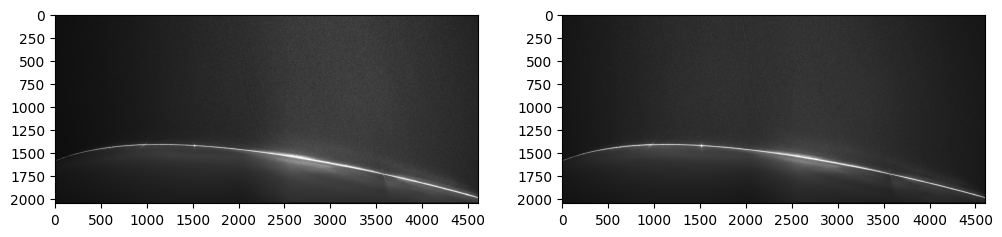

In [7]:
#@title Load the images
# Load the images.
test_dir = tutorial_path + "test2/"
tif_files = glob(os.path.join(test_dir + '*.tif'))

# Show the images.
frame_a = cv2.imread(tif_files[0], cv2.IMREAD_ANYDEPTH)
frame_b = cv2.imread(tif_files[1], cv2.IMREAD_ANYDEPTH)

fig, axs = plt.subplots(1, 2, figsize=(12,10))
axs[0].imshow(frame_a, cmap=plt.cm.gray)
axs[1].imshow(frame_b, cmap=plt.cm.gray)

# Modify tick labels and ticks.
tick_step = 250
ht, wd = frame_a.shape
for ax in axs:
    ax.set_xticks(range(0, wd, 2 * tick_step))
    ax.set_yticks(range(0, ht, tick_step))

plt.show()

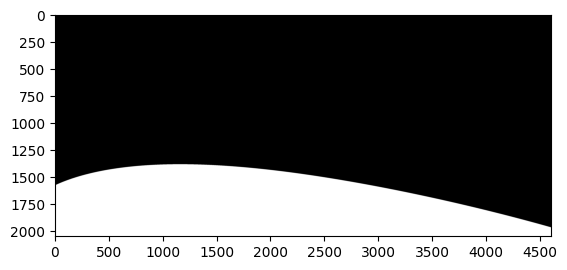

In [8]:
#@title Load the mask
# Load the airfoil mask.
mask = cv2.imread(test_dir + "airfoil_mask.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(mask, cmap=plt.cm.gray)

# Modify tick labels and ticks.
tick_step = 250
plt.xticks(range(0, wd, 2 * tick_step))
plt.yticks(range(0, ht, tick_step))
plt.show()

In [9]:
#@title Feature extraction settings
#@markdown The shape of the images is `(2052, 4603)`.
frame_shape = (2052, 4603) #@param {type:"raw"}
particle_method = "log" #@param ["agt", "log"] {type:"string"}
subpixel_method = "gaussian" #@param ["gaussian", "centroid", "parabolic"] {type:"string"}
threshold = (0.01, 0.01) #@param {type:"raw"}
particle_size = (1, 1) #@param {type:"raw"}
mask = None #@param {type:"raw"}

In [10]:
#@title Perform feature extraction
#@markdown Run this block to identify the particles.
# Initialize the process.
process = ptv_gpu(frame_shape,
                  particle_method=particle_method,
                  subpixel_method=subpixel_method,
                  threshold=threshold,
                  particle_size=particle_size,
                  mask=mask)

coords_a, coords_b = process.get_coords(frame_a, frame_b)

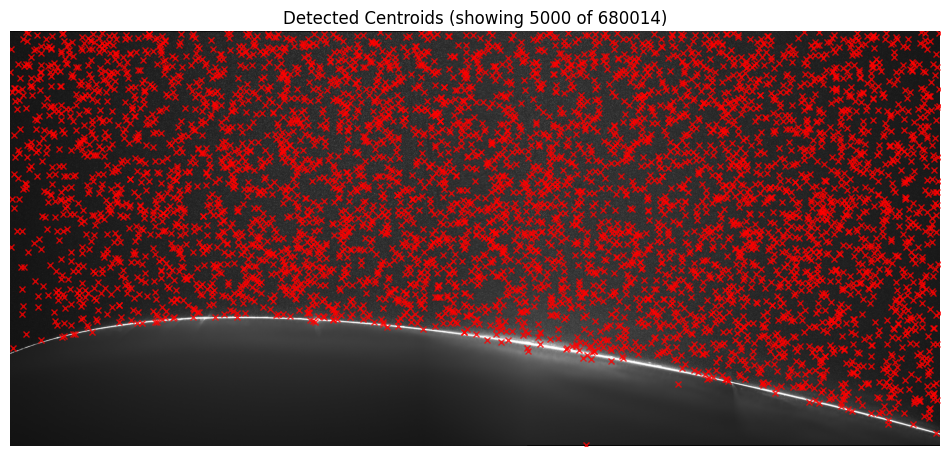

In [11]:
#@title Plot the results
#@markdown Specify number of particles to show.
N = 5000 #@param {type:"raw"}

#@markdown Specify the marker size and color.
marker_size = 4 #@param {type:"slider", min:1, max:10, step:1}
marker_color = "red" #@param ["blue", "red", "yellow"] {type:"string"}

def plot_detected_centroids(frame, coords,
                           step=1,
                           random_sample=None,
                           markersize=marker_size,
                           color=marker_color,
                           alpha=0.8,
                           x_range=None,
                           y_range=None):

    # split coordinates (y, x)
    y, x = coords[:, 0], coords[:, 1]
    total = len(x)
    if random_sample is not None and random_sample < total:
        idx = np.random.choice(total, random_sample, replace=False)
        x, y = x[idx], y[idx]
    elif step > 1:
        x, y = x[::step], y[::step]

    H, W = frame.shape
    if x_range is None:
        x_range = [0, W]
    if y_range is None:
        y_range = [0, H]

    plt.figure(figsize=(12, 10))
    plt.imshow(frame, cmap='gray', origin='upper')
    plt.plot(x, y,
             linestyle='none',
             marker='x',
             color=color,
             markersize=markersize,
             alpha=alpha)

    plt.title(f"Detected Centroids (showing {len(x)} of {total})")
    plt.axis('off')
    plt.xlim(x_range)
    plt.ylim(y_range)
    plt.gca().invert_yaxis()
    plt.show()

plot_detected_centroids(frame_b, coords_b, random_sample=N)

## <span style="color:blue;">References</span>

> Baek, S. J., & Lee, S. J. (1996). A new two-frame particle tracking algorithm using match probability. Experiments in Fluids, 22(1), 23-32.

> Ohmi, K., & Hang-Yu, L. (2000). Particle-tracking velocimetry with new algorithms. Measurement Science and Technology, 11(6), 603-616.

> Pecora, C. (2018). Particle Tracking Velocimetry: A Review.